# Fastcat Demo: Varian kV OBI

In [1]:
%pylab widget
%load_ext autoreload
%autoreload 2

Populating the interactive namespace from numpy and matplotlib


In [19]:
import fastcat as fc
import matplotlib.pyplot as plt
import logging

# Set the logging level for matplotlib to WARNING to suppress DEBUG messages
logging.getLogger('matplotlib').setLevel(logging.WARNING)

# Initialize the spectrum

In [20]:
s = fc.calculate_spectrum(100,14,3,50,monitor=None)

In [21]:
s.attenuate(0.4,fc.get_mu(z=13)) # Aluminum inherent filtration
s.attenuate(0.089,fc.get_mu(z=22)) # Titanium beam hardening filter

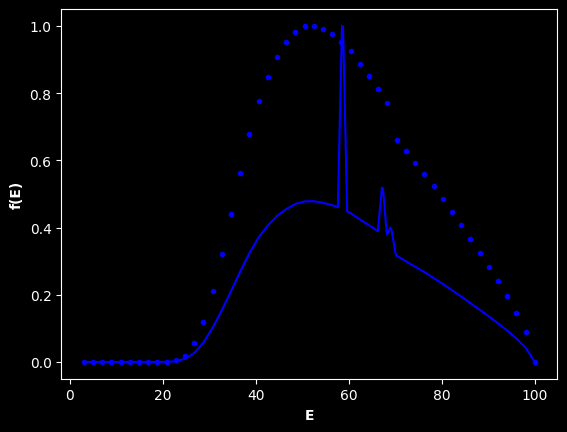

In [22]:
plt.figure()
s.get_plot(plt.subplot())

# Initialize the detector

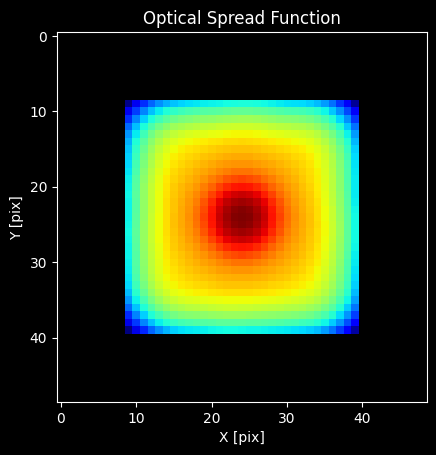

In [13]:
det = fc.Detector(s,'CsI-784-micrometer')
det.add_focal_spot(1.2)

plt.figure()
det.get_plot(plt.subplot())

# Initialize the phantom

In [14]:
phantom = fc.Catphan_404()

# Run the simulation

In [16]:
import numpy as np
angles = np.linspace(0,np.pi*2,180,endpoint=False)
phantom.return_projs(det,s,angles,mgy=0.04,ASG=True,bowtie=True,filter='bowtie_asym')

[2026-05-11 15:37:11,405] {simulate.py:221} INFO - Initializing filter bowtie_asym
[2026-05-11 15:37:11,423] {simulate.py:397} INFO -    Scatter is modified by bowtie
[2026-05-11 15:37:11,423] {simulate.py:429} INFO - Initializing ASG
[2026-05-11 15:37:11,425] {simulate.py:476} INFO -     Interp scatter 512 to 512 pixels
[2026-05-11 15:37:11,425] {simulate.py:476} INFO -     Interp scatter 512 to 512 pixels
[2026-05-11 15:37:11,567] {simulate.py:579} INFO - Running Simulations
[2026-05-11 15:37:11,568] {simulate.py:582} INFO -     1.2 mm focal spot added
[2026-05-11 15:37:11,569] {simulate.py:606} INFO -     Simulating 10 keV
[2026-05-11 15:37:12,825] {simulate.py:606} INFO -     Simulating 20 keV
[2026-05-11 15:37:13,478] {simulate.py:606} INFO -     Simulating 30 keV
[2026-05-11 15:37:14,117] {simulate.py:606} INFO -     Simulating 40 keV
[2026-05-11 15:37:14,802] {simulate.py:606} INFO -     Simulating 50 keV
[2026-05-11 15:37:15,594] {simulate.py:606} INFO -     Simulating 60 keV
[

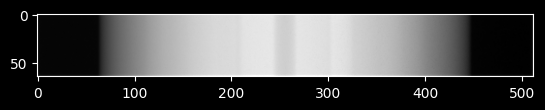

In [17]:
plt.figure()
plt.imshow(phantom.proj[90],cmap='gray')

# Reconstruct

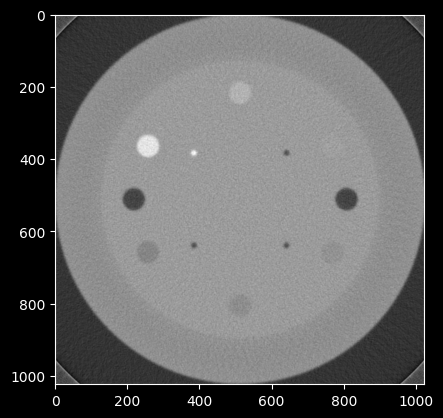

In [18]:
phantom.reconstruct('FDK',filt='ram_lak')

plt.figure()
plt.imshow(phantom.img[5],cmap='gray')